<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-01 22:52:45--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  59.9MB/s    in 3.3s    

2026-01-01 22:52:48 (60.4 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [3]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 148.5 MB/s eta 0:00:00


In [4]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 132.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 135.9 MB/s eta 0:00:00


In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [6]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [7]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [8]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [9]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


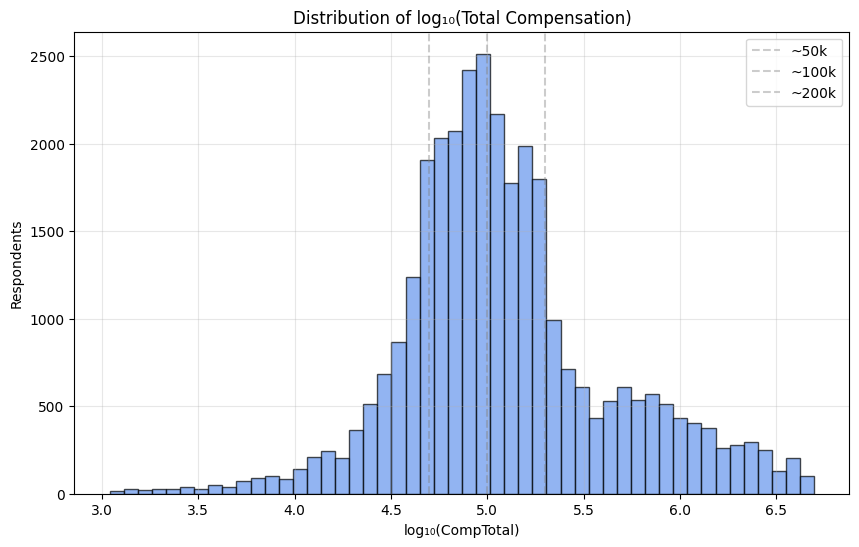

In [79]:
## Write your code here
df_clean = df[(df['CompTotal'] > 1000) & (df['CompTotal'] < 5_000_000)]

plt.figure(figsize=(10, 6))
plt.hist(np.log10(df_clean['CompTotal']), bins=50, edgecolor='black', color='cornflowerblue', alpha=0.7)
# Vertical reference lines for common salary levels
plt.axvline(np.log10(50000),  color='gray',  alpha=0.4, linestyle='--', label='~50k')
plt.axvline(np.log10(100000), color='gray',  alpha=0.4, linestyle='--', label='~100k')
plt.axvline(np.log10(200000), color='gray',  alpha=0.4, linestyle='--', label='~200k')
plt.legend()
plt.title('Distribution of log₁₀(Total Compensation)')
plt.xlabel('log₁₀(CompTotal)')
plt.ylabel('Respondents')
plt.grid(True, alpha=0.3)
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


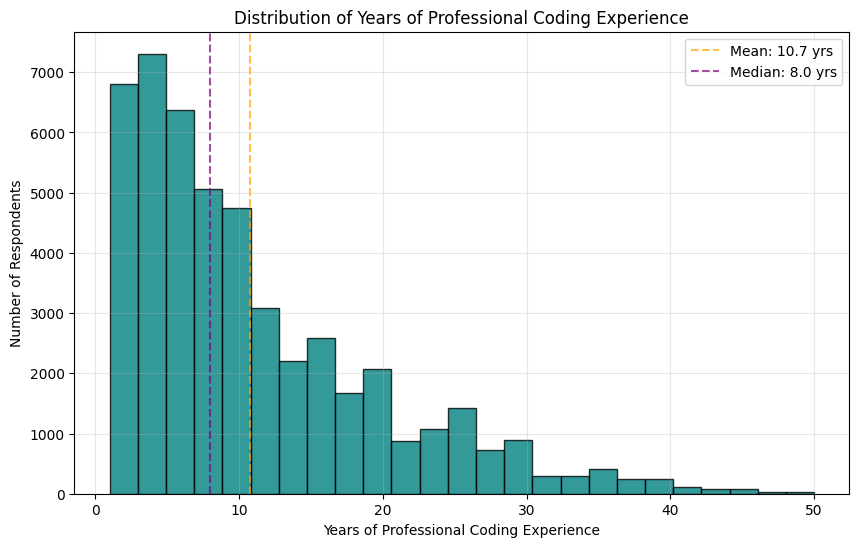

In [84]:
## Write your code here
query = """
SELECT YearsCodePro 
FROM main 
WHERE YearsCodePro IS NOT NULL
"""
df = pd.read_sql_query(query, conn)

# Non-numeric values into NaN
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Clean and filter
df_clean = df[
    df['YearsCodePro'].notnull() &
    (df['YearsCodePro'] >= 0) &
    (df['YearsCodePro'] <= 50)
]

plt.figure(figsize=(10, 6))
plt.hist(df_clean['YearsCodePro'],
         bins=25,
         edgecolor='black',
         color='teal',
         alpha=0.8)

plt.title('Distribution of Years of Professional Coding Experience')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Number of Respondents')
plt.grid(True, alpha=0.3)

# Mean / median lines
if not df_clean.empty:
    mean_exp = df_clean['YearsCodePro'].mean()
    median_exp = df_clean['YearsCodePro'].median()
    plt.axvline(mean_exp, color='orange', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_exp:.1f} yrs')
    plt.axvline(median_exp, color='purple', linestyle='--', alpha=0.7,
                label=f'Median: {median_exp:.1f} yrs')
    plt.legend()

plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


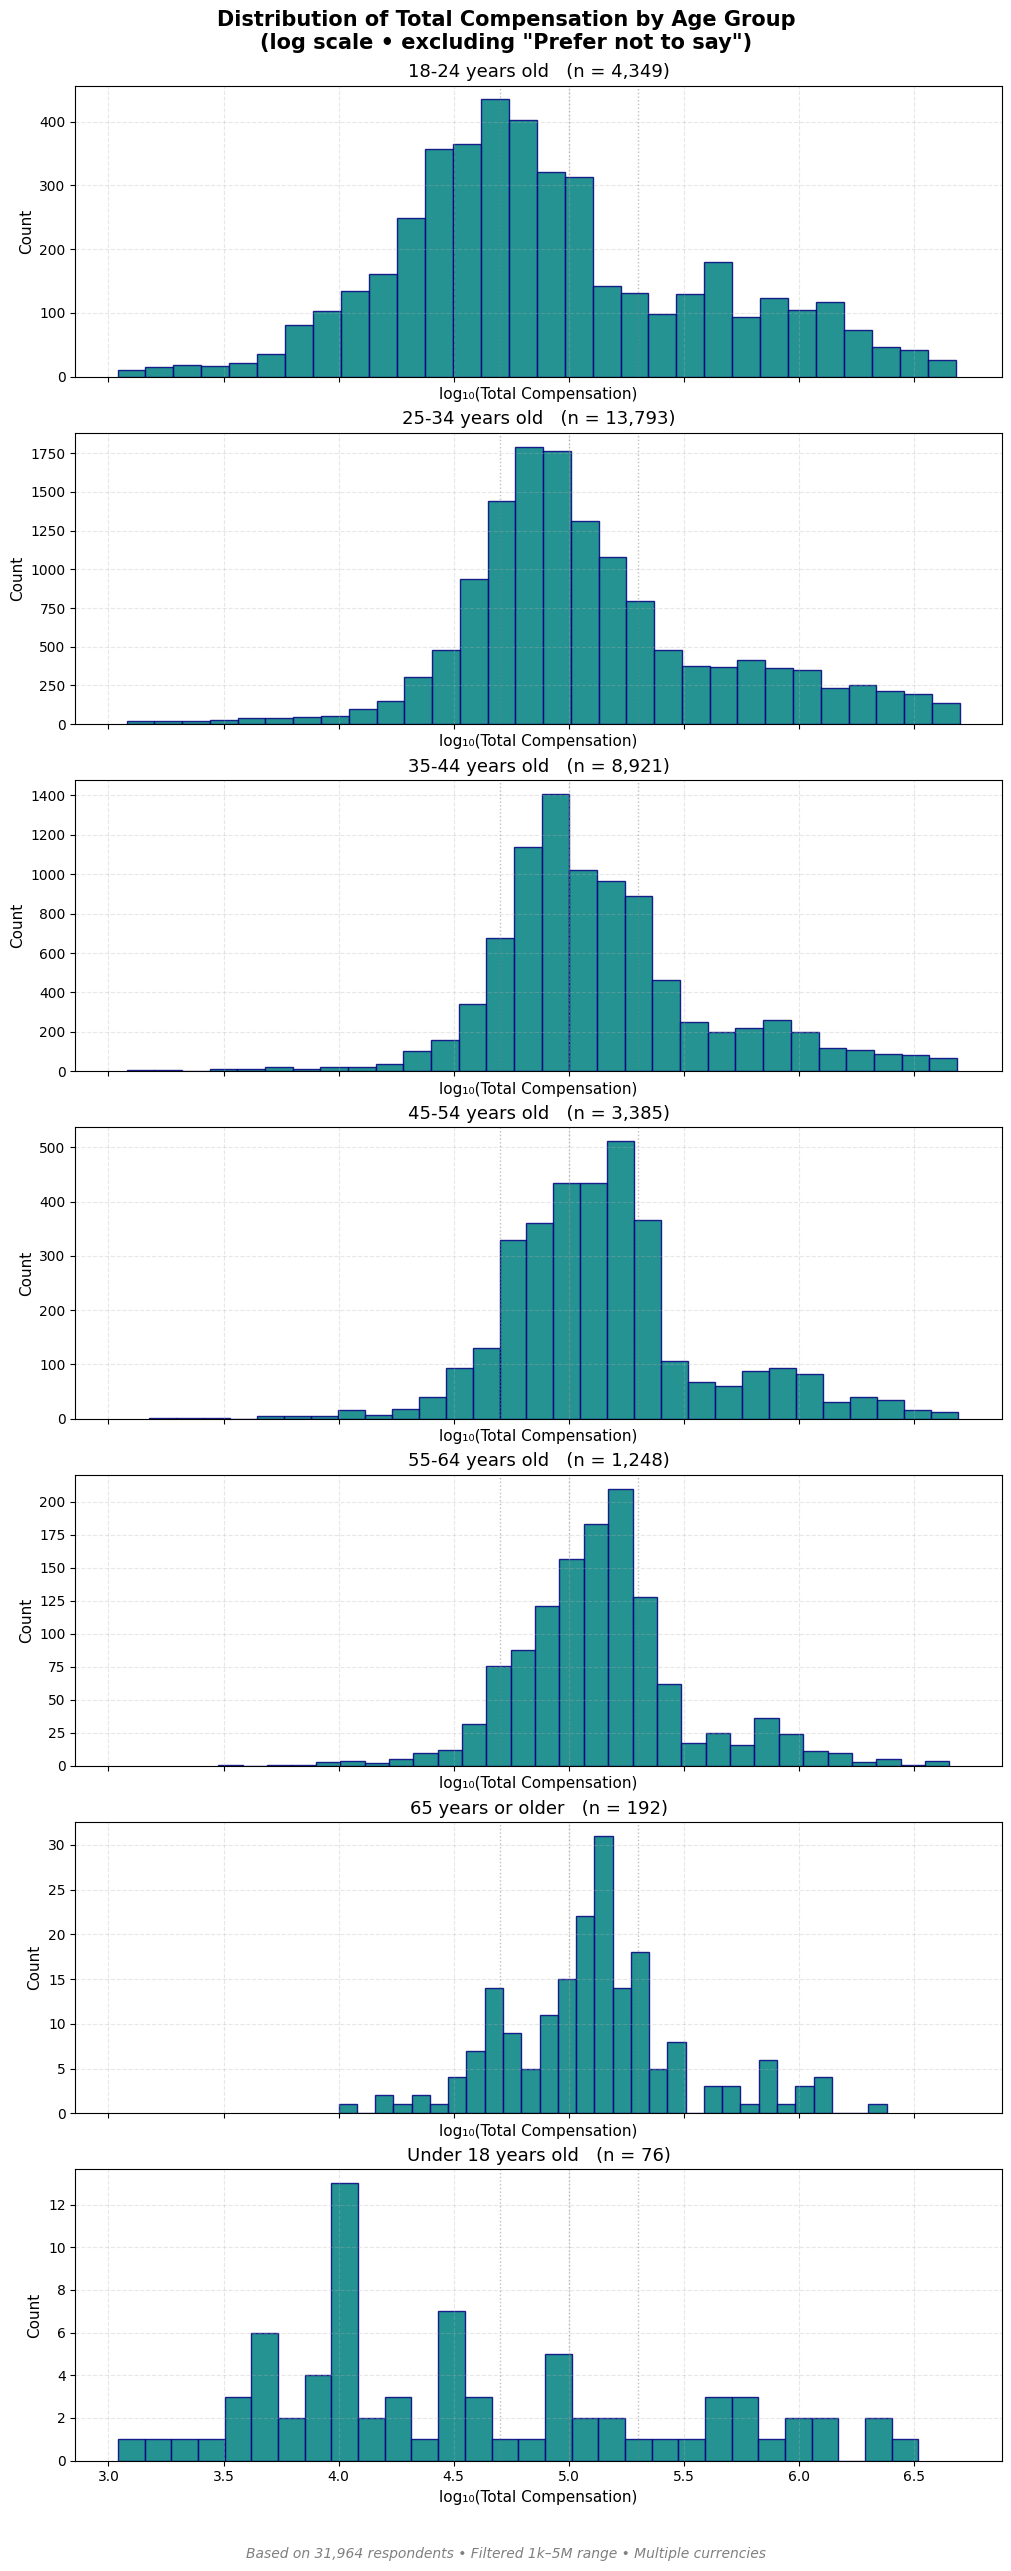

Total respondents after filtering: 31,964
Number of age groups shown: 7


In [167]:
## Write your code here
query = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal > 1000 AND CompTotal < 5000000
  AND Age IS NOT NULL
"""
df = pd.read_sql_query(query, conn)

if 'log_comp' not in df.columns:
    df['log_comp'] = np.log10(df['CompTotal'])

# Exclude "Prefer not to say" etc.
exclude_phrases = ["prefer not to say", "prefer not", "i prefer", "prefer to not"]
mask = ~df['Age'].str.lower().str.contains('|'.join(exclude_phrases), na=False)
df_filtered = df[mask].copy()

# Side-by-side (faceted) histograms
age_groups = sorted(df_filtered['Age'].unique())
n_groups = len(age_groups)

# Dynamic figure size
fig, axes = plt.subplots(n_groups, 1, 
                         figsize=(10, 3.5 * n_groups),
                         sharex=True, 
                         constrained_layout=True)

# Handle case when there's only one group
if n_groups == 1:
    axes = [axes]

for ax, age_group in zip(axes, age_groups):
    data = df_filtered[df_filtered['Age'] == age_group]['log_comp']
    n = len(data)
    
    if n > 5:  # skip tiny groups
        ax.hist(data, bins=30, color='teal', alpha=0.85, edgecolor='navy')
        ax.set_title(f'{age_group}   (n = {n:,})', fontsize=13)
        ax.set_xlabel('log₁₀(Total Compensation)', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Reference lines (50k, 100k, 200k)
        for val in [50000, 100000, 200000]:
            ax.axvline(np.log10(val), color='gray', linestyle=':', alpha=0.5, lw=1)

fig.suptitle('Distribution of Total Compensation by Age Group\n(log scale • excluding "Prefer not to say")',
             fontsize=15, fontweight='bold', y=1.02)

# Context note 
fig.text(0.5, -0.02,
         f'Based on {len(df_filtered):,} respondents • Filtered 1k–5M range • Multiple currencies',
         ha='center', fontsize=10, color='gray', style='italic')

plt.show()

# Summary stats 
print(f"Total respondents after filtering: {len(df_filtered):,}")
print(f"Number of age groups shown: {n_groups}")

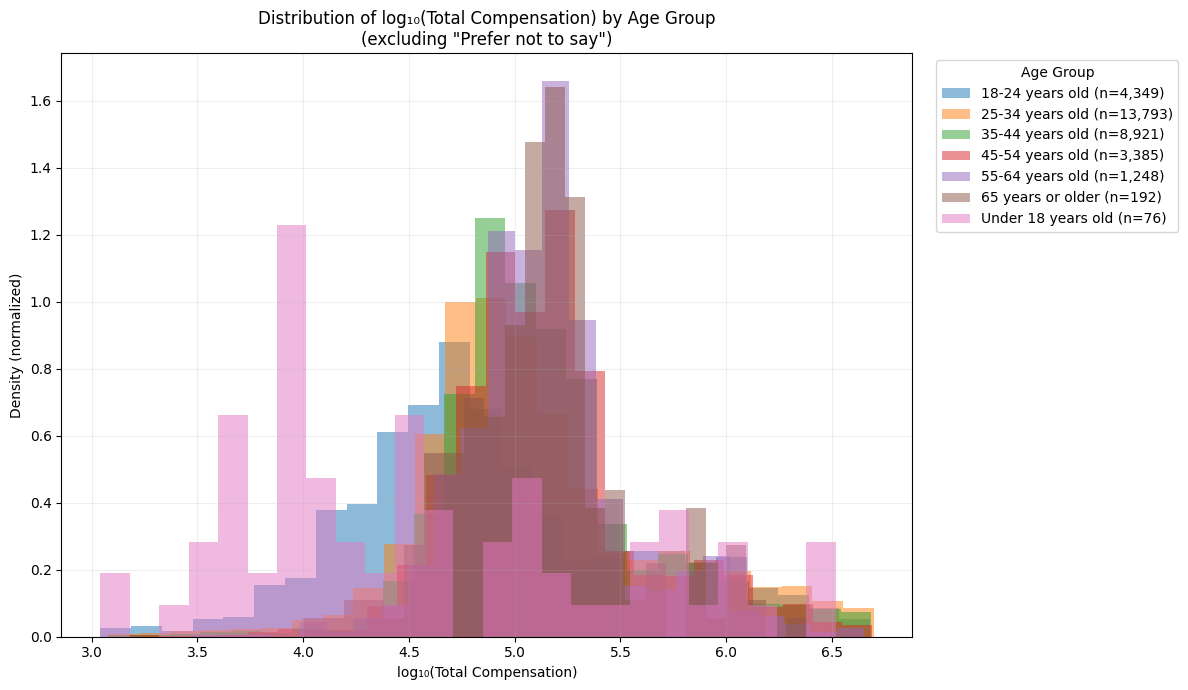

Original rows: 31,978
Rows after excluding 'Prefer not to say': 31,964
Rows removed: 31,978 - 31,964 = 14


In [101]:
# I filtered out "Prefer not to say" because it does not help age counts
df['log_comp'] = np.log10(df['CompTotal'])

exclude_phrases = ["prefer not to say", "prefer not", "i prefer", "prefer to not"]
mask = ~df['Age'].str.lower().str.contains('|'.join(exclude_phrases), na=False)

df_filtered = df[mask].copy()

plt.figure(figsize=(12, 7))

for age_group in sorted(df_filtered['Age'].unique()):
    data = df_filtered[df_filtered['Age'] == age_group]['log_comp']
    if len(data) > 5:  # skip very small groups
        plt.hist(data, bins=25, alpha=0.5, label=f"{age_group} (n={len(data):,})", 
                 density=True)

plt.title('Distribution of log₁₀(Total Compensation) by Age Group\n(excluding "Prefer not to say")')
plt.xlabel('log₁₀(Total Compensation)')
plt.ylabel('Density (normalized)')
plt.legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Number of rows before and after excluding prefer not to say 
print(f"Original rows: {len(df):,}")
print(f"Rows after excluding 'Prefer not to say': {len(df_filtered):,}")
print(f"Rows removed: {len(df):,} - {len(df_filtered):,} = {len(df) - len(df_filtered):,}")

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


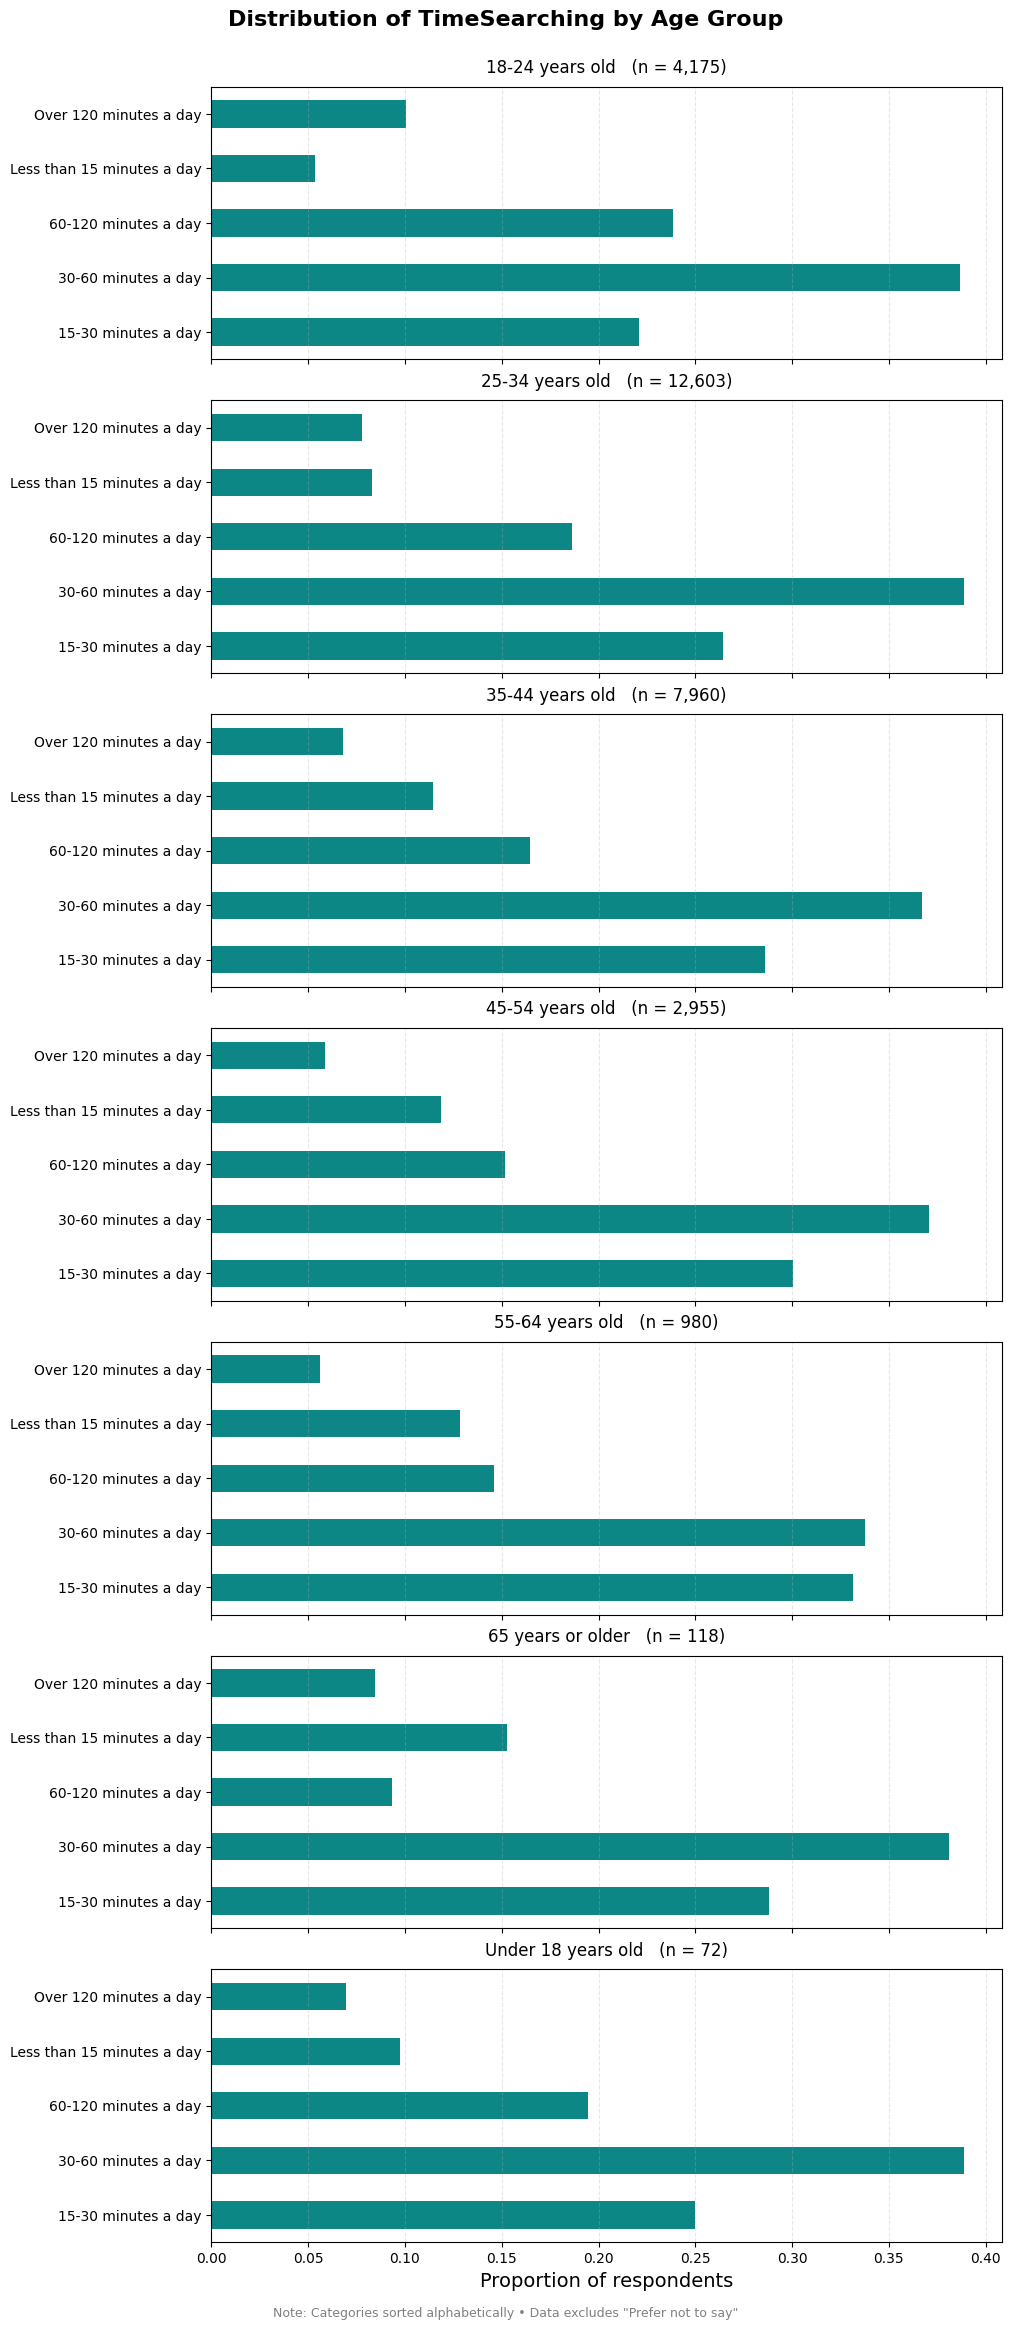

In [124]:
query = """
SELECT Age, TimeSearching
FROM main
WHERE TimeSearching IS NOT NULL
  AND Age IS NOT NULL
"""
df = pd.read_sql_query(query, conn)

# Excludes "Prefer not to say"
exclude_phrases = ["prefer not to say", "prefer not", "i prefer", "prefer to not"]
mask = ~df['Age'].str.lower().str.contains('|'.join(exclude_phrases), na=False)
df_filtered = df[mask].copy()

# Figure with multiple subplots
age_groups = sorted(df_filtered['Age'].unique())
n_groups = len(age_groups)

fig, axes = plt.subplots(n_groups, 1, figsize=(10, 3.2 * n_groups),
                         sharex=True, constrained_layout=True)

# In case there's only one group, make axes iterable
if n_groups == 1:
    axes = [axes]

# Plot each age group in its own subplot
for ax, age in zip(axes, age_groups):
    subset = df_filtered[df_filtered['Age'] == age]['TimeSearching']
    
    # Count and normalize (proportion)
    counts = subset.value_counts(normalize=True).sort_index()
    
    # Horizontal bar for better readability of category names
    counts.plot(kind='barh', color='teal', alpha=0.95, ax=ax)
    
    # Titles & labels with custom sizes
    ax.set_title(f'{age}   (n = {len(subset):,})', fontsize=12, pad=10)
    ax.set_xlabel('Proportion of respondents', fontsize=14)
    ax.set_ylabel('')  # no y label needed since title shows age
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

# Overall figure title
fig.suptitle('Distribution of TimeSearching by Age Group',
             fontsize=16, fontweight='bold', y=1.02)

# Optional: common legend or note
fig.text(0.5, -0.01, 'Note: Categories sorted alphabetically • Data excludes "Prefer not to say"',
         ha='center', fontsize=10-1, color='gray')

plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [129]:
## Write your code here
uery = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
  AND DatabaseWantToWorkWith != ''
"""
df = pd.read_sql_query(query, conn)

print("Current columns in df:")
print(df.columns.tolist())

Current columns in df:
['Age', 'TimeSearching']


In [130]:
import pandas as pd

columns_info = pd.read_sql_query("PRAGMA table_info(main)", conn)
print("All columns in 'main' table:")
print(columns_info[['name', 'type']].to_string(index=False))

# Bonus: look for anything database-related
print("\nLikely candidates:")
for col in columns_info['name']:
    if any(word in col.lower() for word in ['db', 'database', 'want', 'future', 'desire', 'next', 'learn']):
        print("→", col)

All columns in 'main' table:
                          name    type
                    ResponseId INTEGER
                    MainBranch    TEXT
                           Age    TEXT
                    Employment    TEXT
                    RemoteWork    TEXT
                         Check    TEXT
              CodingActivities    TEXT
                       EdLevel    TEXT
                     LearnCode    TEXT
               LearnCodeOnline    TEXT
                       TechDoc    TEXT
                     YearsCode    TEXT
                  YearsCodePro    TEXT
                       DevType    TEXT
                       OrgSize    TEXT
             PurchaseInfluence    TEXT
                    BuyNewTool    TEXT
                    BuildvsBuy    TEXT
                   TechEndorse    TEXT
                       Country    TEXT
                      Currency    TEXT
                     CompTotal    REAL
        LanguageHaveWorkedWith    TEXT
        LanguageWantToWorkWith    T

Loaded 42,558 responses


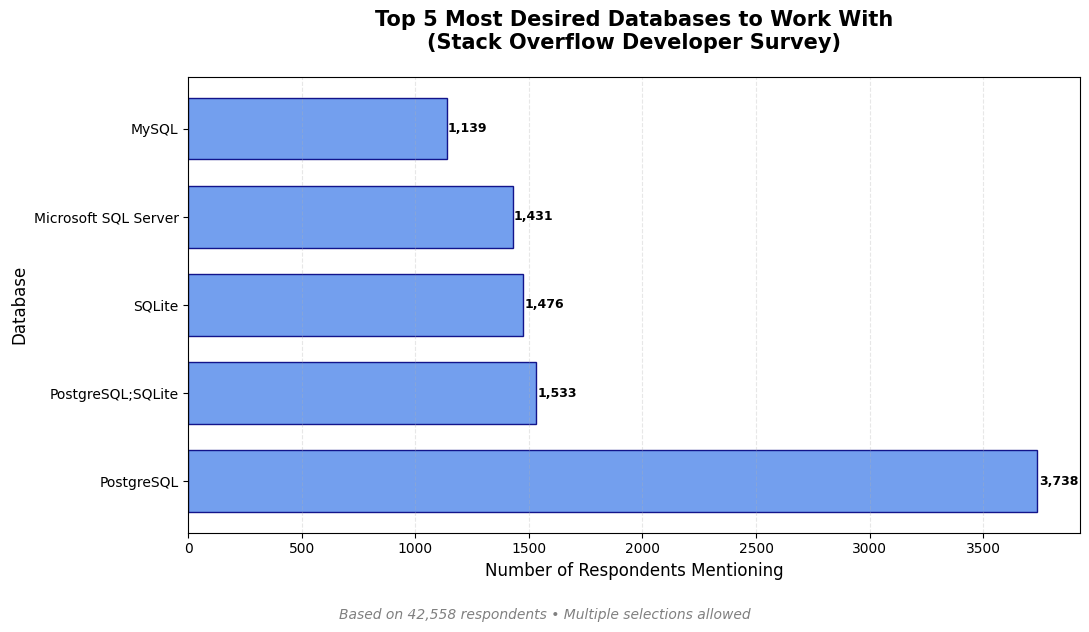


Top 10 Most Desired Databases:
dbs
PostgreSQL              3738
PostgreSQL;SQLite       1533
SQLite                  1476
Microsoft SQL Server    1431
MySQL                   1139


In [155]:
query = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
  AND DatabaseWantToWorkWith != ''
  AND DatabaseWantToWorkWith != 'None'
"""
df = pd.read_sql_query(query, conn)

print(f"Loaded {len(df):,} responses")

# Split comma-separated values (e.g. "PostgreSQL, MongoDB, Redis")
df['dbs'] = df['DatabaseWantToWorkWith'].str.split(r'\s*,\s*')
exploded = df.explode('dbs')

# Clean: remove empty/NaN and strip whitespace
exploded['dbs'] = exploded['dbs'].str.strip()
exploded = exploded[exploded['dbs'].notna() & (exploded['dbs'] != '')]

counts = exploded['dbs'].value_counts()

# Top 5 most desired
top_5 = counts.head(5)

plt.figure(figsize=(11, 6))

# Plot with most popular at TOP
bars = plt.barh(top_5.index[::-1], top_5.values[::-1], 
                color='cornflowerblue', edgecolor='navy', alpha=0.9, height=0.7)

# Count labels ON bars
for bar in bars:
    width = bar.get_width()
    x_pos = width * 1.002 if width > 1000 else width + 50
    color = 'white' if width > 1000 else 'black'
    plt.text(x_pos, bar.get_y() + bar.get_height()/2, f'{int(width):,}', 
             va='center', fontsize=9, fontweight='bold', color='black')

plt.title('Top 5 Most Desired Databases to Work With\n(Stack Overflow Developer Survey)', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Respondents Mentioning', fontsize=12)
plt.ylabel('Database', fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.gca().invert_yaxis()  # Most popular at top
plt.tight_layout()

# Context note
plt.figtext(0.5, -0.04, f'Based on {len(df):,} respondents • Multiple selections allowed', 
            ha='center', fontsize=10, style='italic', color='gray')

plt.show()

# Show full top 10
print("\nTop 10 Most Desired Databases:")
print(top_5.head(10).to_string())

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


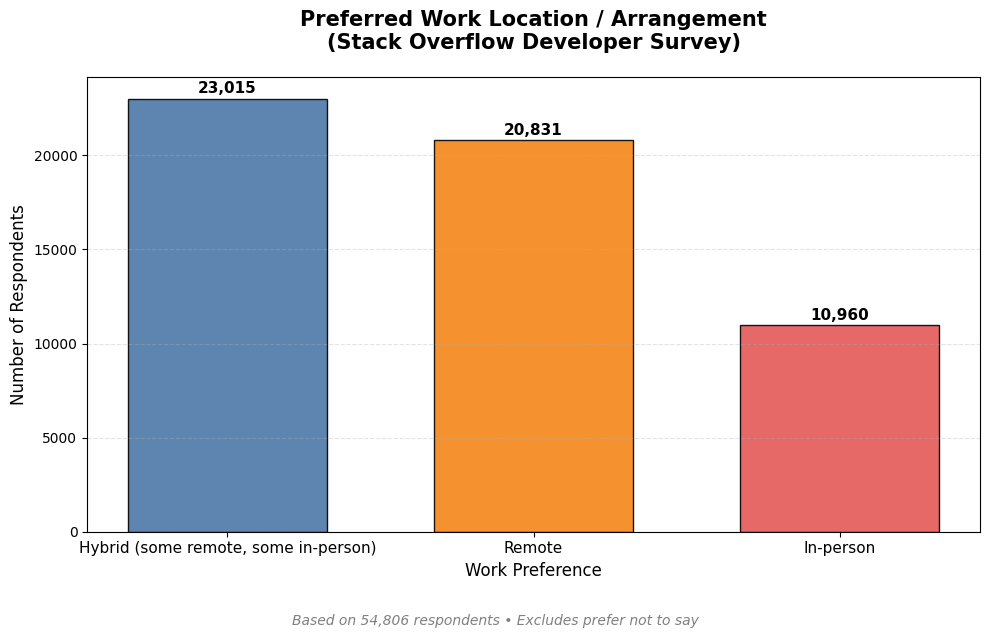

Loaded 54,806 responses with RemoteWork information

Full distribution of RemoteWork preferences:
RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960


In [162]:
## Write your code here
query = """
SELECT RemoteWork
FROM main
WHERE RemoteWork IS NOT NULL
  AND RemoteWork != ''
  AND RemoteWork != 'None'
"""
df = pd.read_sql_query(query, conn)

# Count frequencies
counts = df_clean['RemoteWork'].value_counts()

plt.figure(figsize=(10, 6))

bars = plt.bar(counts.index, counts.values,
               color=['#4C78A8', '#F58518', '#E45756'],
               edgecolor='black', alpha=0.9, width=0.65)

# Count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005*max(counts),
             f'{int(height):,}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.title('Preferred Work Location / Arrangement\n(Stack Overflow Developer Survey)',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Work Preference', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.grid(axis='y', alpha=0.35, linestyle='--')
plt.xticks(rotation=0, ha='center', fontsize=11)
plt.tight_layout()

# Context note
plt.figtext(0.5, -0.05,
            f'Based on {len(df_clean):,} respondents • Excludes prefer not to say',
            ha='center', fontsize=10, style='italic', color='gray')

plt.show()

# For reference: show full distribution
print(f"Loaded {len(df):,} responses with RemoteWork information")
print("\nFull distribution of RemoteWork preferences:")
print(counts.to_string())

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


Number of respondents aged ~45–60: 4,633


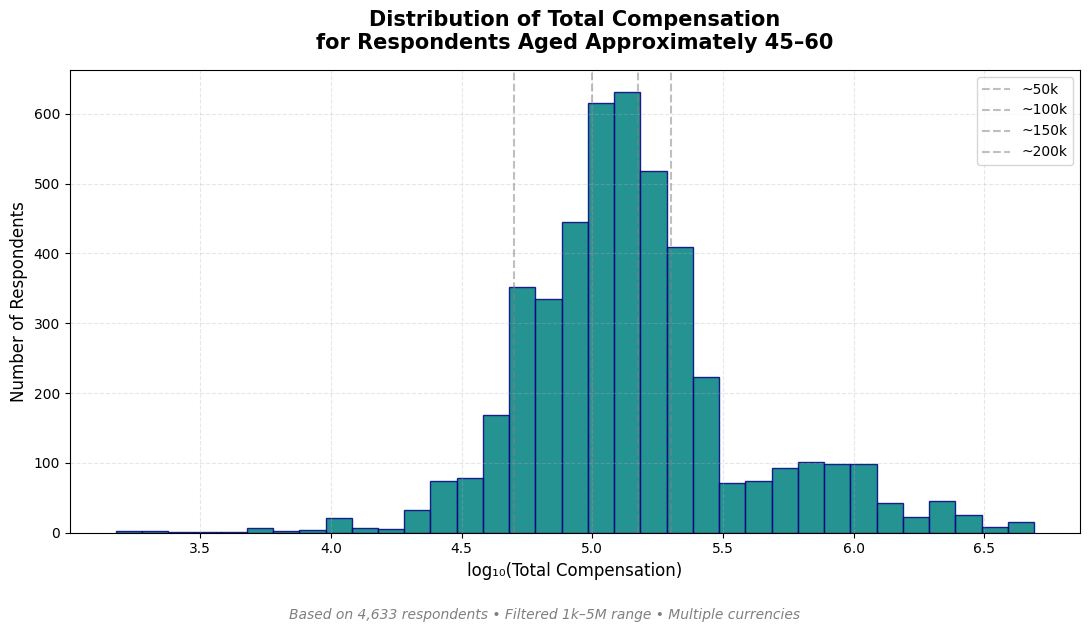


Compensation statistics for age 45–60 group:
count       4633.0
mean      262820.0
std       461247.0
min         1500.0
25%        80000.0
50%       130000.0
75%       200000.0
max      4900000.0
Name: CompTotal, dtype: float64


In [163]:
## Write your code here
query = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL
  AND CompTotal > 1000
  AND CompTotal < 5000000     -- reasonable upper limit
  AND Age IS NOT NULL
"""
df = pd.read_sql_query(query, conn)

# Filter for age group 45–60 
# Handle common age string formats
age_mask = df['Age'].str.contains('45-54|55-64|45–54|55–64|45 to 54|55 to 64', case=False, na=False)
df_mid = df[age_mask].copy()

print(f"Number of respondents aged ~45–60: {len(df_mid):,}")

# Log transform for better visualization 
df_mid['log_comp'] = np.log10(df_mid['CompTotal'])

plt.figure(figsize=(11, 6))

plt.hist(df_mid['log_comp'], 
         bins=35, 
         color='teal', 
         edgecolor='navy', 
         alpha=0.85,
         density=False)

# Vertical reference lines for common salary levels
plt.axvline(np.log10(50000),  color='gray', linestyle='--', alpha=0.5, label='~50k')
plt.axvline(np.log10(100000), color='gray', linestyle='--', alpha=0.5, label='~100k')
plt.axvline(np.log10(150000), color='gray', linestyle='--', alpha=0.5, label='~150k')
plt.axvline(np.log10(200000), color='gray', linestyle='--', alpha=0.5, label='~200k')

plt.title('Distribution of Total Compensation\nfor Respondents Aged Approximately 45–60', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('log₁₀(Total Compensation)', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--', which='both')
plt.legend()
plt.tight_layout()

# Context note
plt.figtext(0.5, -0.04, 
            f'Based on {len(df_mid):,} respondents • Filtered 1k–5M range • Multiple currencies',
            ha='center', fontsize=10, color='gray', style='italic')

plt.show()

# Quick statistical summary
print("\nCompensation statistics for age 45–60 group:")
print(df_mid['CompTotal'].describe().round(0))

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


Loaded 28,356 responses with JobSat and YearsCodePro


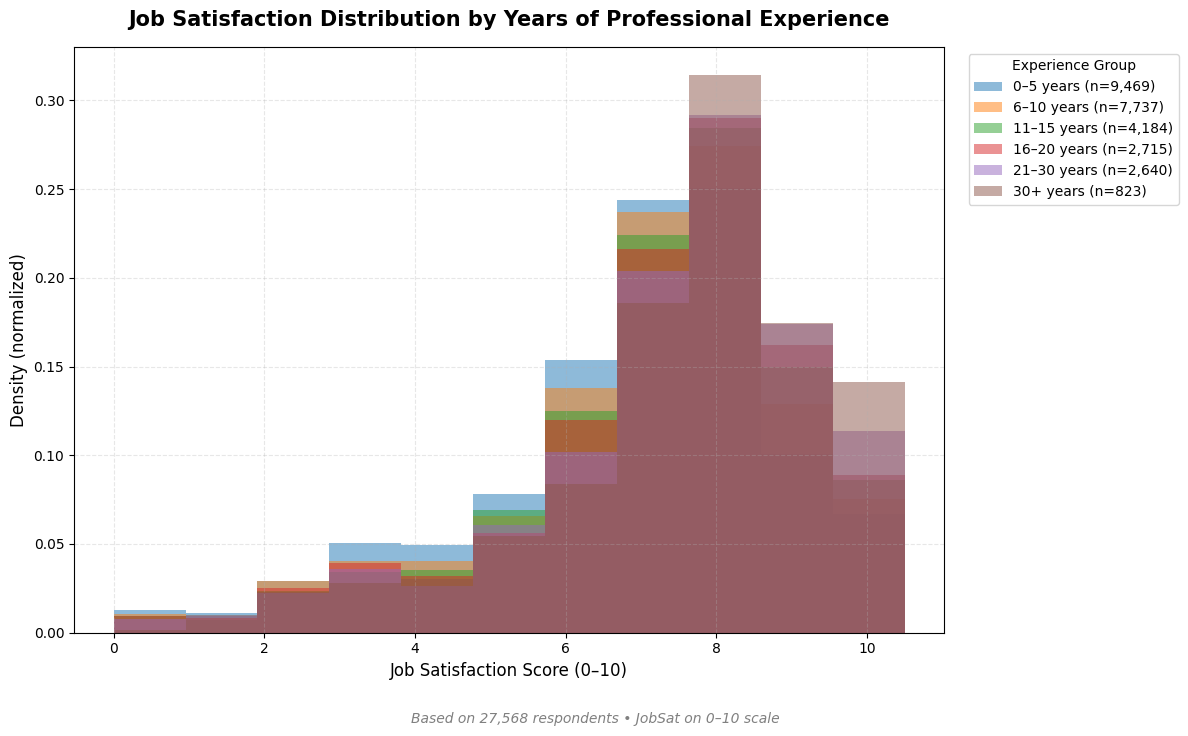

In [164]:
## Write your code here
query = """
SELECT JobSat, YearsCodePro
FROM main
WHERE JobSat IS NOT NULL
  AND YearsCodePro IS NOT NULL
"""
df = pd.read_sql_query(query, conn)

print(f"Loaded {len(df):,} responses with JobSat and YearsCodePro")

# Convert YearsCodePro to numeric 
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Drop rows where conversion failed
df = df[df['YearsCodePro'].notna()]

# Define experience groups 
bins = [0, 5, 10, 15, 20, 30, np.inf]
labels = ['0–5 years', '6–10 years', '11–15 years', '16–20 years', '21–30 years', '30+ years']

df['ExpGroup'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels, right=True)

# Overlaid histograms 
plt.figure(figsize=(12, 7))

for group in labels:
    subset = df[df['ExpGroup'] == group]['JobSat']
    if len(subset) > 50:  # only plot groups with reasonable size
        plt.hist(subset, bins=11, range=(0,10.5), alpha=0.5, 
                 label=f'{group} (n={len(subset):,})',
                 density=True)  # normalize so shapes are comparable

plt.title('Job Satisfaction Distribution by Years of Professional Experience',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Job Satisfaction Score (0–10)', fontsize=12)
plt.ylabel('Density (normalized)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Experience Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.figtext(0.5, -0.04,
            f'Based on {len(df):,} respondents • JobSat on 0–10 scale',
            ha='center', fontsize=10, color='gray', style='italic')

plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
